# Recommender System

A. Build system
1. Objective
2. Load data
3. Explore ratings (check for feasibility)
4. Filter users and games
5. Create user-item matrix
6. Compute item-item similarity
7. Recommend similar games to a given game
8. Recommend games for a user
9. Make outputs readable

B. Evaluate and improve
1. Build popularity baseline
2. Add simple improvements

C. Conclusions and next steps



⛔️ **TO DO: INTRO / CONTEXT**

🎯 goal: recommend games based on user behaviour (collaborative filtering)

### Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

## Load data

In [2]:
# Load ratings df (core data set for recommender)
DATA_DIR = Path("../raw_data")

ratings = pd.read_csv(DATA_DIR / "user_ratings.csv")
ratings.head()

,BGGId,Rating,Username
0,213788,8.0,Tonydorrf
1,213788,8.0,tachyon14k
2,213788,8.0,Ungotter
3,213788,8.0,brainlocki3
4,213788,8.0,PPMP


In [3]:
# Load games df with core data only
games = pd.read_csv(DATA_DIR / "games.csv")
games_clean = games[["BGGId", "Name", "NumUserRatings"]].copy()

games_clean.head()


,BGGId,Name,NumUserRatings
0,1,Die Macher,5354
1,2,Dragonmaster,562
2,3,Samurai,15146
3,4,Tal der Könige,340
4,5,Acquire,18655


In [4]:
# Check for duplicates in games
games_clean["BGGId"].duplicated().sum()

np.int64(0)

In [5]:
# Check for missing values in games
games_clean.isnull().sum()

BGGId             0
Name              0
NumUserRatings    0
dtype: int64

## Explore Ratings data

In [6]:
ratings.shape

(18942215, 3)

In [7]:
# Check for duplicates
ratings.duplicated().sum()

np.int64(0)

In [8]:
# Check for missing values
ratings.isna().sum().sort_values(ascending=False)

Username    63
BGGId        0
Rating       0
dtype: int64

In [9]:
# Basic counts
n_users = ratings["Username"].nunique()
n_games = ratings["BGGId"].nunique()
n_ratings = len(ratings)

print(f"Unique users: {n_users:,}")
print(f"Unique games rated: {n_games:,}")
print(f"Total ratings: {n_ratings:,}")

Unique users: 411,374
Unique games rated: 21,925
Total ratings: 18,942,215


In [10]:
# DECISION: Drop 63 rows with missing usernames (vs 411k unique users)
ratings = ratings.dropna(subset=["Username"])

In [11]:
# Average ratings per user and game
ratings_per_user = ratings.groupby("Username")["BGGId"].count()
ratings_per_game = ratings.groupby("BGGId")["Username"].count()

print("\nRatings per user:")
print(ratings_per_user.describe())

print("\nRatings per game:")
print(ratings_per_game.describe())


Ratings per user:
count    411374.000000
mean         46.046060
std         108.431797
min           1.000000
25%           2.000000
50%          12.000000
75%          44.000000
max        6493.000000
Name: BGGId, dtype: float64

Ratings per game:
count     21925.000000
mean        863.952201
std        3627.070586
min           7.000000
25%          57.000000
50%         125.000000
75%         398.000000
max      107760.000000
Name: Username, dtype: float64


In [12]:
# Sparsity estimate: How many possible ratings are we missing?
possible_ratings = n_users * n_games
sparsity = 1 - (n_ratings / possible_ratings)

print(f"\nApproximate matrix sparsity: {sparsity:.1%}")


Approximate matrix sparsity: 99.8%


### 🙋‍♀️ Ratings Data – Initial Assessment

The ratings dataset is large and high quality, with ~19M ratings across ~411k users and ~22k games. 

User activity is highly skewed: while the mean number of ratings per user is ~46, the median is 12, indicating a long tail of casual users alongside a smaller group of highly active users. A similar pattern exists for games, with a median of 125 ratings but some games exceeding 100k ratings.

The user–item matrix is extremely sparse (~99.8%), which is expected for recommender systems. Despite this, there is enough overlap in user behaviour (multiple ratings per user and per game) to support collaborative filtering.

**So what?**

The data is well-suited to an item-based collaborative filtering approach. 

However, the long tail of low-activity users and low-rated games is likely to introduce noise. As a result, the next step is to filter the dataset to retain only:

- users with a minimum number of ratings (e.g. ≥10)
- games with a minimum number of ratings (e.g. ≥20)

This will reduce sparsity, improve the reliability of similarity calculations, and lead to more meaningful recommendations.

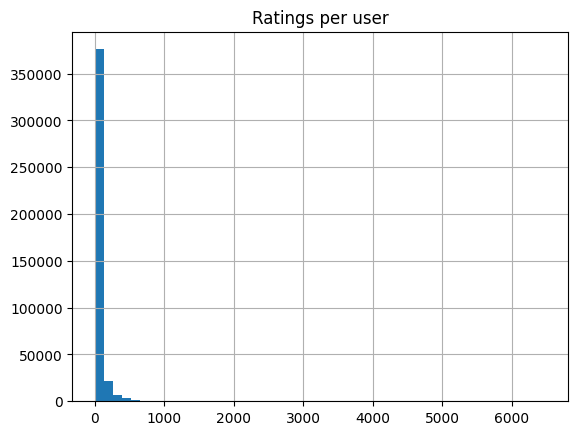

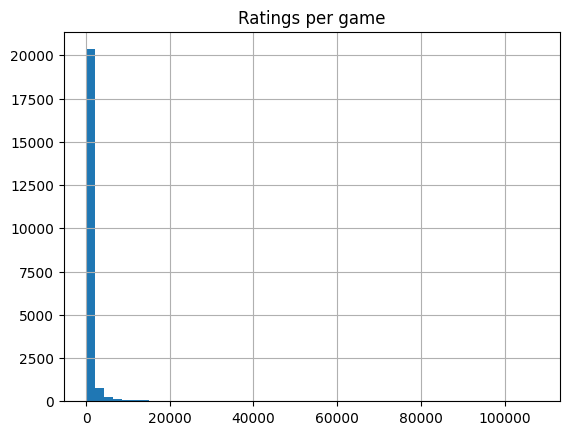

In [13]:
# ---- Visualise distributions ----

# Ratings per user
ratings_per_user.hist(bins=50)
plt.title("Ratings per user")
plt.show()

# Ratings per games
ratings_per_game.hist(bins=50)
plt.title("Ratings per game")
plt.show()


In [14]:
# Check key percentiles
ratings_per_user.quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25      2.0
0.50     12.0
0.75     44.0
0.90    115.0
0.95    198.0
Name: BGGId, dtype: float64

In [15]:
ratings_per_game.quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25      57.0
0.50     125.0
0.75     398.0
0.90    1481.6
0.95    3228.6
Name: Username, dtype: float64

In [16]:
# Set recommended thresholds
min_user_ratings = 10
min_game_ratings = 50

# ----- Check impact of thresholds -----

# Filter active users
active_users = ratings_per_user[ratings_per_user >= min_user_ratings].index
ratings_filtered = ratings[ratings["Username"].isin(active_users)]

# Filter popular games
popular_games = ratings_filtered["BGGId"].value_counts()
popular_games = popular_games[popular_games >= min_game_ratings].index

# Combine
ratings_filtered = ratings_filtered[ratings_filtered["BGGId"].isin(popular_games)]

# Check
retained = len(ratings_filtered) / len(ratings)

print("Original ratings:", len(ratings))
print("Filtered ratings:", len(ratings_filtered))
print(f"Retained: {retained:.2%}")

print("Users:", ratings_filtered["Username"].nunique())
print("Games:", ratings_filtered["BGGId"].nunique())

Original ratings: 18942152
Filtered ratings: 18194617
Retained: 96.05%
Users: 224604
Games: 17165


## User-item matrix

Allows us to compare games based on how users rated them, and compare users based on what they liked.

In [17]:
# One row per user, one column per game, ratings inside the matrix
user_item_matrix = ratings_filtered.pivot_table(
    index="Username",
    columns="BGGId",
    values="Rating",
    aggfunc="mean" # how to combine multiple ratings from one user
)

print(user_item_matrix.shape)
user_item_matrix.iloc[:5, :5]

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_32350/1549050647.py:2: PerformanceWarning: The following operation may generate 3855327660 cells in the resulting pandas object.
  user_item_matrix = ratings_filtered.pivot_table(


(224604, 17165)


BGGId,1,2,3,4,5
Username,,,,,
mycroft,NaN,NaN,NaN,NaN,8.0
-=Yod@=-,NaN,NaN,NaN,NaN,NaN
-Johnny-,5.0,NaN,4.0,NaN,7.0
-Loren-,NaN,NaN,NaN,NaN,NaN
-LucaS-,NaN,NaN,NaN,NaN,NaN


In [18]:
# Do some users now have zero ratings post filtering?
empty_users = user_item_matrix.isna().all(axis=1).sum()
empty_users

np.int64(0)

🙋‍♀️ Given the size of the matrix (over 3 billion cells), we'll work with a smaller group of top-rated games to get this working well first...

In [19]:
# Define subset
top_5k_games = (ratings_filtered["BGGId"].value_counts().head(5000).index)

# Filter to subset
ratings_small = ratings_filtered[ratings_filtered["BGGId"].isin(top_5k_games)].copy()

print("Subset shape:", ratings_small.shape)
print("Unique games:", ratings_small["BGGId"].nunique())

Subset shape: (16325573, 3)
Unique games: 5000


In [20]:
# Build smaller user-item matrix
user_item_matrix_small = ratings_small.pivot_table(
    index="Username",
    columns="BGGId",
    values="Rating",
    aggfunc="mean"
)

print(user_item_matrix.shape)

(224604, 17165)


In [21]:
# ----- Prepare for item-item similarity -----

# Transpose -> rows = games, columns = users
item_user_matrix = user_item_matrix_small.T

# Fill NaN with 0 to enable calculations
item_user_matrix = item_user_matrix.fillna(0)

item_user_matrix.shape

(5000, 224544)

In [22]:
# Compute cosine similarity
item_similarity = cosine_similarity(item_user_matrix)

# Convert to dataframe with rows and columns as game IDs
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.shape

(5000, 5000)

In [23]:
# ----- Check results -----

# Pick an example game
example_game = item_similarity_df.index[0]

# Show 10most similar games
similar_games = (item_similarity_df[example_game].sort_values(ascending=False).head(10))

similar_games.to_list()

[0.999999999999954,
 0.3694471646268327,
 0.36255091985642107,
 0.35345352752669057,
 0.3502652050873121,
 0.3477269012418889,
 0.34401834703851963,
 0.3394767995287788,
 0.3248568322887566,
 0.3246135947107317]

In [ ]:
# ----- Add game names for readability -----

# Create lookup
bggid_to_name = dict(zip(games_clean["BGGId"], games_clean["Name"]))

# Remove original games from similar game set
similar_games = similar_games.drop(index=example_game)

# Convert to dataframe
similar_df = pd.DataFrame({
    "BGGId": similar_games.index,
    "Score": similar_games.values
})

# Map names
similar_df["Name"] = similar_df["BGGId"].map(bggid_to_name)

similar_df[["Name", "Score"]]

,Name,Score
0,Age of Steam,0.369447
1,Goa,0.362551
2,Taj Mahal,0.353454
3,Imperial,0.350265
4,The Princes of Florence,0.347727
5,Amun-Re,0.344018
6,Indonesia,0.339477
7,Ra,0.324857
8,Automobile,0.324614


In [ ]:
# Get the name of the example game
example_name = bggid_to_name.get(example_game, "Unknown")

print(f"Similar to: {example_name}")
similar_df[["Name", "Score"]]

Similar to: Die Macher


,Name,Score
0,Age of Steam,0.369447
1,Goa,0.362551
2,Taj Mahal,0.353454
3,Imperial,0.350265
4,The Princes of Florence,0.347727
5,Amun-Re,0.344018
6,Indonesia,0.339477
7,Ra,0.324857
8,Automobile,0.324614


In [27]:
# Test with a more mainstream game
games_clean[games_clean["Name"].str.contains("Wingspan", case=False, na=False)]

,BGGId,Name,NumUserRatings
19608,266192,Wingspan,54404


In [28]:

# Define WingSpan ID
wingspan_game = 266192

similar_to_wingspan = (item_similarity_df[wingspan_game].sort_values(ascending=False).head(10))

similar_to_wingspan = similar_to_wingspan.drop(wingspan_game)

# Convert to DataFrame
wingspan_df = pd.DataFrame({
    "BGGId": similar_to_wingspan.index,
    "Score": similar_to_wingspan.values
})

# Add game names
bggid_to_name = dict(zip(games_clean["BGGId"], games_clean["Name"]))
wingspan_df["Name"] = wingspan_df["BGGId"].map(bggid_to_name)

print("Similar to: WingSpan")
wingspan_df[["Name", "Score"]]

Similar to: WingSpan


,Name,Score
0,Azul,0.549159
1,Terraforming Mars,0.527954
2,Everdell,0.495875
3,The Quacks of Quedlinburg,0.486587
4,Scythe,0.482292
5,7 Wonders Duel,0.477327
6,Viticulture Essential Edition,0.468371
7,Sagrada,0.432760
8,Codenames,0.429195


#### 💡 Reflection: Item-Based Collaborative Filtering

An item-based collaborative filtering model was created that identifies similar games based on shared user rating patterns, without using explicit game features.

Initial results show strong, coherent recommendations. For example, querying for Wingspan returns a mix of medium-weight strategy and engine-building games (e.g. Terraforming Mars, Everdell, Viticulture), alongside some lighter but widely played titles (e.g. Azul, Codenames). This suggests the model is capturing both mechanical similarity and shared audience preferences.

Similarity scores are relatively modest (~0.3–0.5), which is expected given the sparsity of the data. In this context, the ranking and coherence of recommendations are more important than absolute values.

A key observation is a mild popularity bias - Widely rated games appear more frequently due to stronger interaction signals. This can be beneficial in reinforcing reliable, high-confidence recommendations, though it may reduce exposure to more niche titles.

*Rather than treating this purely as a flaw, it may be better seen as a product trade-off: some users will value familiar, high-confidence recommendations, while others may prefer more niche discovery. This could be addressed through simple controls, such as allowing users to explore more “hidden gem” recommendations.*